In [1]:
!pip install pillow

In [3]:
# !pip install pillow

import math
from PIL import Image
import matplotlib.pyplot as plt

Total images: 12
People: ['hamza', 'ali']
Each image = 2500 numbers


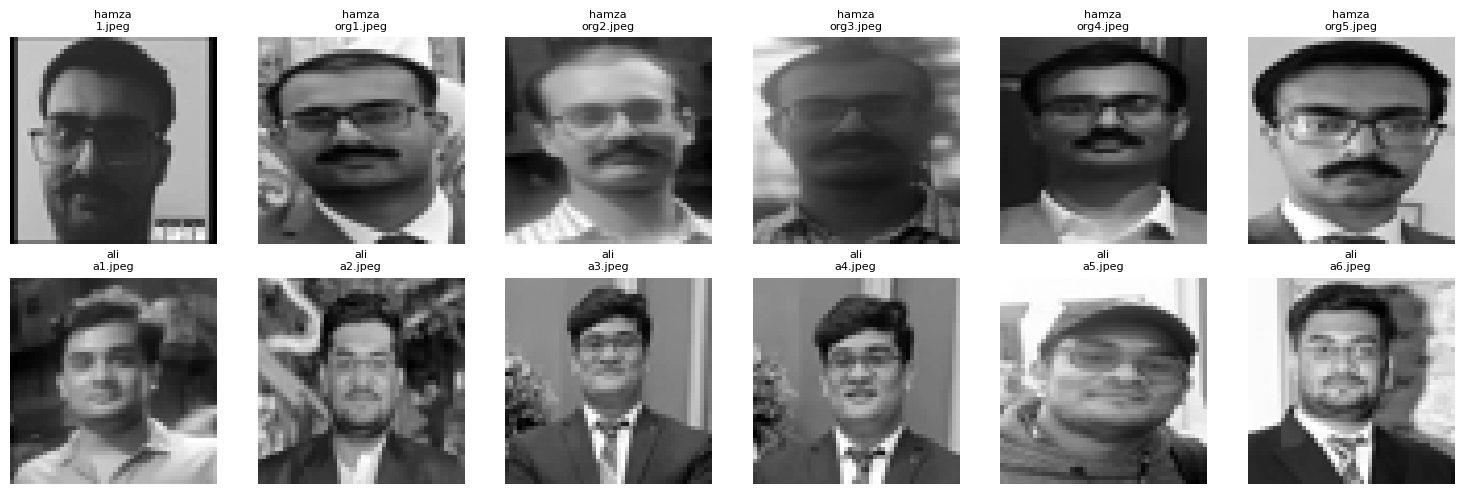

In [16]:
# ✏️ Organize by PERSON (each person has multiple images)
PERSON_IMAGES = {
    "hamza": ["1.jpeg", "org1.jpeg", "org2.jpeg", "org3.jpeg", "org4.jpeg", "org5.jpeg"],
    "ali": ["a1.jpeg", "a2.jpeg", "a3.jpeg", "a4.jpeg", "a5.jpeg", "a6.jpeg"],
}

SIZE = (50, 50)  # all images resized to 50x50

def load_image(path):
    img = Image.open(path).convert("L").resize(SIZE)
    pixels = list(img.getdata())
    return [p / 255.0 for p in pixels]  # normalize 0-1

# Flatten into one list for training
all_images = []
labels = []
for person, files in PERSON_IMAGES.items():
    for f in files:
        all_images.append(load_image(f))
        labels.append(person)

print(f"Total images: {len(all_images)}")
print(f"People: {list(PERSON_IMAGES.keys())}")
print(f"Each image = {len(all_images[0])} numbers")

# Show all images organized by person
total_imgs = len(all_images)
fig, axes = plt.subplots(2, 6, figsize=(15, 5))  # 2 rows (people) x 6 cols (images)
axes = axes.flatten()

idx = 0
for person, files in PERSON_IMAGES.items():
    for fname in files:
        vec = all_images[idx]
        grid = [[vec[r*SIZE[0]+c] for c in range(SIZE[0])] for r in range(SIZE[1])]
        axes[idx].imshow(grid, cmap='gray')
        axes[idx].set_title(f"{person}\n{fname}", fontsize=8)
        axes[idx].axis('off')
        idx += 1

plt.tight_layout()
plt.show()

## Step 3-Mean Face

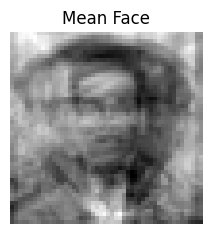

Mean subtracted ✓


In [17]:
N = len(all_images)
D = len(all_images[0])

# Average all faces together
mean = [sum(all_images[n][d] for n in range(N)) / N for d in range(D)]

# Show mean face
grid = [[mean[r*SIZE[0]+c] for c in range(SIZE[0])] for r in range(SIZE[1])]
plt.figure(figsize=(2.5, 2.5))
plt.imshow(grid, cmap='gray')
plt.title("Mean Face")
plt.axis('off')
plt.show()

# Subtract mean from every image
centered = [[all_images[n][d] - mean[d] for d in range(D)] for n in range(N)]
print("Mean subtracted ✓")

##Step 4- math helpers

In [18]:
def dot(a, b):       return sum(a[i]*b[i] for i in range(len(a)))
def norm(v):         return math.sqrt(dot(v, v))
def normalize(v):    n = norm(v); return [x/n for x in v]
def transpose(A):    return [list(r) for r in zip(*A)]
def matvec(A, v):    return [sum(A[i][j]*v[j] for j in range(len(v))) for i in range(len(A))]

def matmul(A, B):
    res = [[0.0]*len(B[0]) for _ in range(len(A))]
    for i in range(len(A)):
        for j in range(len(B[0])):
            for k in range(len(B)):
                res[i][j] += A[i][k] * B[k][j]
    return res

##Step-5 Find EigenFaces

In [19]:
# ✏️ How many eigenfaces to find (can't exceed number of images)
K = 3

# Build small surrogate matrix L = A^T * A
A = transpose(centered)         # D x N
L = matmul(transpose(A), A)    # N x N  (small!)

# Power iteration — finds one eigenvector at a time
def power_iter(A, iters=200):
    b = [1.0] * len(A)
    for _ in range(iters):
        Ab = matvec(A, b)
        n  = norm(Ab)
        if n == 0: break
        b  = [x/n for x in Ab]
    return dot(b, matvec(A, b)), b   # eigenvalue, eigenvector

# Extract K eigenvectors using deflation
L_copy = [row[:] for row in L]
small_vecs = []
for i in range(K):
    val, vec = power_iter(L_copy)
    small_vecs.append(vec)
    # Remove this eigenvector from matrix (deflation)
    for r in range(len(L_copy)):
        for c in range(len(L_copy)):
            L_copy[r][c] -= val * vec[r] * vec[c]
    print(f"Eigenface {i+1} found ✓")

# Lift small eigenvectors → full D-dimensional eigenfaces
eigenfaces = [normalize(matvec(A, v)) for v in small_vecs]
print(f"\n{K} eigenfaces ready!")

Eigenface 1 found ✓
Eigenface 2 found ✓
Eigenface 3 found ✓

3 eigenfaces ready!


## Step 6-visualize eigenfaces

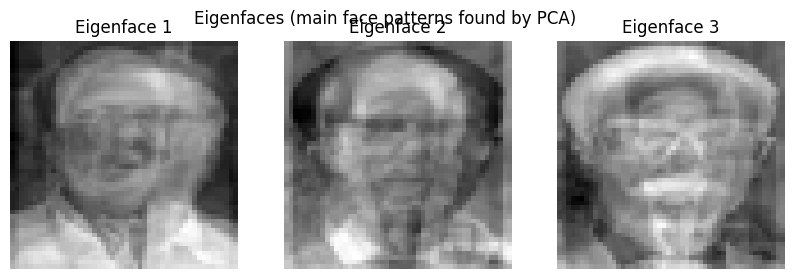

In [20]:
fig, axes = plt.subplots(1, K, figsize=(10, 3))
for i, (ax, ef) in enumerate(zip(axes, eigenfaces)):
    grid = [[ef[r*SIZE[0]+c] for c in range(SIZE[0])] for r in range(SIZE[1])]
    ax.imshow(grid, cmap='gray')
    ax.set_title(f"Eigenface {i+1}")
    ax.axis('off')
plt.suptitle("Eigenfaces (main face patterns found by PCA)")
plt.show()

## Step 7-Recognize a face

In [22]:
# ✏️ Which image do you want to recognize?
QUERY = "testali.jpeg"

def project(vec):
    centered_vec = [vec[d] - mean[d] for d in range(D)]
    return [dot(centered_vec, ef) for ef in eigenfaces]

# Project all training images
gallery=[]
for person, files in PERSON_IMAGES.items():
    person_weights=[project(load_image(f)) for f in files]
    avg_w=[sum(p[i] for p in person_weights)/len(person_weights) for i in range(K)]
    gallery.append({"name":person,"w":avg_w})
# Project query image
query_vec  = load_image(QUERY)
query_w    = project(query_vec)

# Find closest match by distance
def dist(a, b): return math.sqrt(sum((a[i]-b[i])**2 for i in range(len(a))))

results = sorted(gallery, key=lambda e: dist(query_w, e["w"]))

print(f"Query  : {QUERY}")
print(f"Match  : {results[0]['name']}  (distance = {dist(query_w, results[0]['w']):.4f})")
print()
print("Full ranking:")
for r in results:
    print(f"  {dist(query_w, r['w']):.4f}  →  {r['name']}")

Query  : testali.jpeg
Match  : ali  (distance = 6.6373)

Full ranking:
  6.6373  →  ali
  7.8613  →  hamza


In [23]:
# ✏️ Which image do you want to recognize?
QUERY = "hamzatest.jpeg"

def project(vec):
    centered_vec = [vec[d] - mean[d] for d in range(D)]
    return [dot(centered_vec, ef) for ef in eigenfaces]

# Project all training images
gallery=[]
for person, files in PERSON_IMAGES.items():
    person_weights=[project(load_image(f)) for f in files]
    avg_w=[sum(p[i] for p in person_weights)/len(person_weights) for i in range(K)]
    gallery.append({"name":person,"w":avg_w})
# Project query image
query_vec  = load_image(QUERY)
query_w    = project(query_vec)

# Find closest match by distance
def dist(a, b): return math.sqrt(sum((a[i]-b[i])**2 for i in range(len(a))))

results = sorted(gallery, key=lambda e: dist(query_w, e["w"]))

print(f"Query  : {QUERY}")
print(f"Match  : {results[0]['name']}  (distance = {dist(query_w, results[0]['w']):.4f})")
print()
print("Full ranking:")
for r in results:
    print(f"  {dist(query_w, r['w']):.4f}  →  {r['name']}")

Query  : hamzatest.jpeg
Match  : hamza  (distance = 9.1454)

Full ranking:
  9.1454  →  hamza
  13.0031  →  ali
